# DSCI632 - Fake News Detection

## PySpark Setup

In [ ]:
import sys
!"{sys.executable}" -m pip install pyspark==3.2.1 findspark


^C


     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.0/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/281.4 MB ? eta -:--:--
     ---------------------------------------- 0.3/2

In [1]:
!wget -q https://archive.apache.org/dist/spark/spark-3.2.0/spark-3.2.0-bin-hadoop2.7.tgz
!tar xf spark-3.2.0-bin-hadoop2.7.tgz

'wget' is not recognized as an internal or external command,
operable program or batch file.
tar: Error opening archive: Failed to open 'spark-3.2.0-bin-hadoop2.7.tgz'


In [ ]:
import os
import findspark

# ✅ Update this path according to your folder location
PROJECT_PATH = r"D:\REPOS\Fake-News-Detection-PySpark"
SPARK_PATH = PROJECT_PATH + r"\spark-3.2.0-bin-hadoop2.7"

# ✅ Set Spark Home
os.environ["SPARK_HOME"] = SPARK_PATH

# ✅ Optional (only needed if you installed winutils)
# os.environ["HADOOP_HOME"] = r"C:\hadoop"

# ✅ Initialize findspark
findspark.init(SPARK_PATH)

print("SPARK_HOME =", os.environ["SPARK_HOME"])


ModuleNotFoundError: No module named 'findspark'

In [3]:
!pip install findspark


In [1]:
!pip install pyspark==3.2.1 findspark


In [6]:
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.22.7-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ["PATH"]

print("JAVA_HOME set to:", os.environ["JAVA_HOME"])

!pip install -q findspark
!pip install pyspark

!git clone https://github.com/avivfaraj/DSCI632-Project.git

JAVA_HOME set to: C:\Program Files\Eclipse Adoptium\jdk-11.0.22.7-hotspot


fatal: destination path 'DSCI632-Project' already exists and is not an empty directory.


## Important packages

In [7]:
# NLP
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords


# Pandas is required to read the data.
# For some reason pyspark can't read the csv file correctly
# So we have to read using pandas and then convert to spark DF
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType,StructField, StringType, IntegerType
from pyspark.ml.feature import IDF, Tokenizer, VectorAssembler
from pyspark.ml.feature import StopWordsRemover, CountVectorizer
from pyspark.ml import Pipeline, PipelineModel
from pyspark.sql.functions import when, col, regexp_replace, concat, lit, length
from pyspark.sql.types import FloatType, DoubleType
from pyspark.ml.classification import NaiveBayesModel, NaiveBayes
from pyspark.mllib.evaluation import BinaryClassificationMetrics

In [ ]:
def evaluate(df, labelCol = "label", predCol = "prediction"):
    TP = df.filter((col(labelCol) == 0) & (col(predCol) == 0)).count()


In [ ]:
    FN = df.filter((col(labelCol) == 1) & (col(predCol) == 0)).count()
    FP = df.filter((col(labelCol) == 0) & (col(predCol) == 1)).count()
    TN = df.filter((col(labelCol) == 1) & (col(predCol) == 1)).count()

    precision = (TP)/(TP+FP)
    recall = (TP)/(TP+FN)
    print("Accuracy: %.3f" % float((TP+TN)/(TP+TN+FP+FN)))
    print("Recall: %.3f" % float(recall))
    print("Precision: %.3f" % float(precision))
    print("F1 Score: %.3f" % float(2*(precision * recall)/(precision +recall)))

    (df
        .crosstab('label','prediction')
        .withColumnRenamed("label_prediction", "label\prediction")
        .orderBy("label\prediction", asceding = False)
        .show()
    )

    return ([[TP, FP], [FN, TN]], precision, recall)

## Spark Session \& Reading Dataset

In [9]:
# =========================
# IMPORTS
# =========================

import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

import seaborn as sns
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.functions import col
from pyspark.ml.feature import IDF, Tokenizer, VectorAssembler
from pyspark.ml.feature import StopWordsRemover, CountVectorizer
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.classification import NaiveBayesModel, NaiveBayes
from pyspark.mllib.evaluation import BinaryClassificationMetrics


# =========================
# START SPARK (Use limited cores)
# =========================

spark = SparkSession.builder \
    .appName("Final Project") \
    .master("local[2]") \
    .getOrCreate()

print("Spark Started Successfully")


# =========================
# DEFINE SCHEMA
# =========================

mySchema = StructType([
    StructField("index", IntegerType(), True),
    StructField("title", StringType(), True),
    StructField("author", StringType(), True),
    StructField("text", StringType(), True),
    StructField("label", IntegerType(), True)
])


# =========================
# READ CSV DIRECTLY WITH SPARK (NO PANDAS)
# =========================

path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    schema=mySchema
)

print("Data Loaded Successfully")
spark_df.show(5)


# =========================
# EVALUATION FUNCTION
# =========================

def evaluate(df, labelCol="label", predCol="prediction"):
    TP = df.filter((col(labelCol) == 0) & (col(predCol) == 0)).count()
    FN = df.filter((col(labelCol) == 1) & (col(predCol) == 0)).count()
    FP = df.filter((col(labelCol) == 0) & (col(predCol) == 1)).count()
    TN = df.filter((col(labelCol) == 1) & (col(predCol) == 1)).count()

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0
    recall = TP / (TP + FN) if (TP + FN) != 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)

    print("Accuracy: %.3f" % accuracy)
    print("Recall: %.3f" % recall)
    print("Precision: %.3f" % precision)
    print("F1 Score: %.3f" % (2 * (precision * recall) / (precision + recall)))

    df.crosstab('label', 'prediction').show()

    return [[TP, FP], [FN, TN]]

Py4JError: An error occurred while calling None.org.apache.spark.sql.SparkSession. Trace:
py4j.Py4JException: Constructor org.apache.spark.sql.SparkSession([class org.apache.spark.SparkContext, class java.util.HashMap]) does not exist
	at py4j.reflection.ReflectionEngine.getConstructor(ReflectionEngine.java:179)
	at py4j.reflection.ReflectionEngine.getConstructor(ReflectionEngine.java:196)
	at py4j.Gateway.invoke(Gateway.java:237)
	at py4j.commands.ConstructorCommand.invokeConstructor(ConstructorCommand.java:80)
	at py4j.commands.ConstructorCommand.execute(ConstructorCommand.java:69)
	at py4j.ClientServerConnection.waitForCommands(ClientServerConnection.java:182)
	at py4j.ClientServerConnection.run(ClientServerConnection.java:106)
	at java.base/java.lang.Thread.run(Thread.java:829)



In [ ]:
spark = SparkSession.builder.appName("Final Project").master("local[*]").getOrCreate()

mySchema = StructType([ StructField("index", IntegerType(), True)\
                       ,StructField("title", StringType(), True)\
                       ,StructField("author", StringType(), True)\
                       ,StructField("text", StringType(), True)\
                       ,StructField("label", IntegerType(), True)])

path = "./DSCI632-Project/data/train.csv"
pandas_df = pd.read_csv(path, header = 0)

spark_df = spark.createDataFrame(pandas_df, schema = mySchema)


KeyboardInterrupt: 

## Pre-processing

### Cleaning Dataset

In [6]:
# Deleting all rows that are missing text
# df_rmv_nan_text = spark_df.filter(col("text") != "NaN")
df_rmv_nan_text = spark_df.filter(length(col("text")) > 60)

# There are a lot of NaN in the dataset.
# Those are Null values in pandas that were
# Converted to NaN string in spark df.
# Since it is a string, it will not be recognized by na() methods
# So, we have to manually change their value:
df_no_nan = (df_rmv_nan_text
             .withColumn("title", when(col("title") == "NaN", " ")
                                            .otherwise(col("title")))
             )


## NOTE: Later on we will use Tokenizer from PySpark MLlib. This tokenizer
##       takes care of converting all characters to lowercase, so it is
##       not required in this step.

# Remove non-character from title and text
df_clean = (df_no_nan

                 ## Removing any non-character from title
                .withColumn("title", 
                            regexp_replace(
                                col('title'),
                                r'[^\w\’ ]',''))
                
                ## Removing any non-character from text
                .withColumn("text", 
                            regexp_replace(
                                col('text'),
                                r'[^\w\’ ]',''))
                
                ## Replacing 2 or more whitespaces with 1 whitespace
                .withColumn("text", 
                            regexp_replace(
                                col('text'),
                                r'[ ]{2,}',' '))
                
                ## Replacing 2 or more whitespaces with 1 whitespace
                .withColumn("title", 
                            regexp_replace(
                                col('text'),
                                r'[ ]{2,}',' '))
                )


# Concatenation of title and text when title doesn't appear in text
df_combined = (df_clean
                    .withColumn('full_text',
                                  when(col("text").contains(
                                                    concat(col("title"))),
                                                    col("text"))
                                  
                                  .otherwise(concat(col("title"),
                                                    lit(" "),
                                                    col("text"))))
                    .select(["full_text","label"])
                    .withColumn("label", col("label").cast(DoubleType()))
                    .dropDuplicates()
                )


# Clean memory             
del df_rmv_nan_text, df_no_nan, df_clean

# Sanity Check
print(df_combined.count())
df_combined.show(7)

20210
+--------------------+-----+
|           full_text|label|
+--------------------+-----+
|0 0 AP N1 26 27 1...|  1.0|
|GREENBELT Md The ...|  0.0|
|The Minnesota off...|  0.0|
|GeoEngineering Un...|  1.0|
|Following a fight...|  0.0|
|The military indu...|  1.0|
|Insists Russia De...|  1.0|
+--------------------+-----+
only showing top 7 rows



### Check Class Balance

Still balanced!

In [7]:
df_combined.groupby("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|  0.0|10385|
|  1.0| 9825|
+-----+-----+



### Stopwords

In [8]:
try:
    stopwords_ls = stopwords.words('english')
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words('english')

# Sanity Check
stopwords_ls[:10]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're"]

### Stemmer Class

In [9]:
####################### Code Citation #######################
# Author: Clare S. Y. Huang
# Date: 01 Aug 2020
# Title: Custom Transformer that can be fitted into Pipeline
# URL: https://csyhuang.github.io/2020/08/01/custom-transformer/
#############################################################

from pyspark import keyword_only
from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol
import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable


class Stemmer(Transformer, 
                 HasInputCol, 
                 HasOutputCol,
                 DefaultParamsReadable, 
                 DefaultParamsWritable):
    
    @keyword_only
    def __init__(self, inputCol = "input", outputCol = "output"):
        super(Stemmer, self).__init__()
        kwargs = self._input_kwargs
        self.set_params(**kwargs)

    @keyword_only
    def set_params(self, inputCol = "input", outputCol = "output"):
        kwargs = self._input_kwargs
        self._set(**kwargs)
    
    def get_input_col(self):
        return self.getOrDefault(self.inputCol)

    def get_output_col(self):
        return self.getOrDefault(self.outputCol)

    def _transform(self, df):

        # Input and output column
        input_col = self.get_input_col()
        output_col = self.get_output_col()

        # Initialize stemmer from nltk package
        ps = PorterStemmer()
        
        # User Defined Function: stemming every word in the input column
        transform_udf = F.udf(lambda x: [ps.stem(word) for word in x], ArrayType(StringType(), False))

        # Return the new df with the new column
        return df.withColumn(output_col, transform_udf(input_col))

# Sanity check
# words = Tokenizer(inputCol="text", outputCol="words").transform(spark_df)
# test = Stem(inputCol = "words", outputCol = "test").transform(words)
# test.select(["words", "test"]).show(4)

## Dummy Classifier

In [10]:
df_dummy = (spark_df
                .withColumn("prediction", 
                    when((col("author") == "NaN") | (col("title") == "NaN") , 1.0)
                    .otherwise(0.0))
                .withColumn("label", col("label").cast(FloatType()))
                .select(["label","prediction"])
            )

df_dummy.show(7)

# Sanity Check
evaluate(df_dummy, predCol = "prediction")

+-----+----------+
|label|prediction|
+-----+----------+
|  1.0|       0.0|
|  0.0|       0.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  1.0|       0.0|
|  0.0|       0.0|
|  1.0|       1.0|
+-----+----------+
only showing top 7 rows

Accuracy: 0.618
Recall: 0.567
Precision: 0.997
F1 Score: 0.723
+----------------+-----+----+
|label\prediction|  0.0| 1.0|
+----------------+-----+----+
|             0.0|10361|  26|
|             1.0| 7924|2489|
+----------------+-----+----+



([[10361, 26], [7924, 2489]], 0.9974968710888611, 0.5666393218485097)

## Machine Learning

### Split Data

In [11]:
# Split data to train and test
train, test = df_combined.randomSplit([0.7,0.3], seed=2)

### Pipeline

***NOTE:*** Fitting the pipeline on the train set takes a while, so I ran it and saved it to a folder "pipeline" within the folder "model and pipeline". To test it, you can load the pipeline model and use it to transform the test and train dataframes in [Load Pipeline](#load). 

#### Pipeline Stages


In [12]:

# Define Stages for pipeline 

# Stage 1 - Tokenizing words
tokenizer = Tokenizer(inputCol="full_text", outputCol="full_text_words")

# Stage 2 - Removing stop words (using nltk stop words)
word_remover = StopWordsRemover(stopWords = stopwords_ls,
                                inputCol = "full_text_words",
                                outputCol = "full_text_words_clean")

# Stage 3 - Lemmatizing each word using custom lemmatizer class
stemmer = Stemmer(inputCol = "full_text_words_clean", outputCol = "stemmed")

# Stage 4 - Term Frequency of every word
tf = CountVectorizer(inputCol="stemmed", outputCol="features", vocabSize = 1e6)

pipeline = Pipeline(stages= [tokenizer, word_remover, stemmer, tf]).fit(train)
train_df = pipeline.transform(train).select(["full_text","features","label"])
test_df = pipeline.transform(test).select(["full_text","features","label"])

#### Save Pipeline

In [13]:
# # #### Save Pipeline! ####
# pipeline.save("./DSCI632-Project/model and pipeline/pipeline")

<a name="load"></a>
#### Load Pipeline 

In [14]:
# pipeline = PipelineModel.load("./DSCI632-Project/model and pipeline/pipeline")
# train_df = pipeline.transform(train).select(["full_text","features","label"])
# test_df = pipeline.transform(test).select(["full_text","features","label"])

### Naive Bayes

***NOTE:*** Fitting Naive Bayes model takes a while. I ran it and saved the model to a folder "Naive Bayes Model" within the folder "model and pipeline". 
To test it, skip the code under *Fit Naive Bayes*, and run [*Load Naive Bayes*](#load-na) instead.

#### Fit Naive Bayes

In [15]:
nb = NaiveBayes(labelCol="label", featuresCol="features", thresholds = [0.6, 0.4])
nb_model = nb.fit(train_df)
predictions_nb = nb_model.transform(test_df)

<a name="load-na"></a>
#### Load Naive Bayes

In [16]:
# nb_model = NaiveBayesModel.load("./DSCI632-Project/model and pipeline/Naive Bayes Model")
# predictions_nb = nb_model.transform(test_df)
# predictions_nb.select(["label", "prediction"]).show()

#### Save Naive Bayes

In [17]:
# nb_model.save("./DSCI632-Project/model and pipeline/Naive Bayes Model")

### Testing

In [18]:
evaluate(predictions_nb.select(["label","prediction"]))

Accuracy: 0.921
Recall: 0.885
Precision: 0.973
F1 Score: 0.927
+----------------+----+----+
|label\prediction| 0.0| 1.0|
+----------------+----+----+
|             0.0|2985|  84|
|             1.0| 387|2540|
+----------------+----+----+



([[2985, 84], [387, 2540]], 0.9726295210166178, 0.8852313167259787)

In [19]:
predictions_dummy_rdd = df_dummy.select(["label", "prediction"]).rdd.map(tuple)
predictions_nb_rdd = predictions_nb.select(["label", "prediction"]).rdd.map(tuple)

# Instantiate metrics object
metrics_dummy = BinaryClassificationMetrics(predictions_dummy_rdd)
metrics_nb = BinaryClassificationMetrics(predictions_nb_rdd)

print("Area under ROC Baseline: " , metrics_dummy.areaUnderROC)
print("Area under ROC Naive Bayes: " , metrics_nb.areaUnderROC)

/usr/local/lib/python3.7/dist-packages/pyspark/sql/context.py:127: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  FutureWarning


Area under ROC Baseline:  0.7781506748407558
Area under ROC Naive Bayes:  0.9266095608020137


// this is the start 

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.master("local[2]").getOrCreate()

print("Spark is working ✅")

Spark is working ✅


In [2]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Rows:", spark_df.count())
spark_df.show(5)

Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [1]:
# =============================
# IMPORTS
# =============================

# Spark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, concat, lit, length
from pyspark.sql.types import DoubleType

# ML
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import NaiveBayes

# NLP
import nltk
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords

# Utilities
from pyspark import keyword_only
from pyspark.ml import Transformer
from pyspark.ml.param.shared import HasInputCol, HasOutputCol
from pyspark.ml.util import DefaultParamsReadable, DefaultParamsWritable
import pyspark.sql.functions as F
from pyspark.sql.types import ArrayType, StringType

In [2]:
spark = SparkSession.builder \
    .appName("FakeNewsDetection") \
    .master("local[1]") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

print("Spark Started Safely")

Spark Started Safely


In [3]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Rows:", spark_df.count())
spark_df.show(5)

Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5 rows


In [4]:
# Remove very short text
df_filtered = spark_df.filter(length(col("text")) > 60)

# Replace NaN title
df_filtered = df_filtered.withColumn(
    "title",
    regexp_replace(col("title"), "NaN", " ")
)

# Remove non characters
df_clean = (
    df_filtered
    .withColumn("title", regexp_replace(col("title"), r"[^\w\’ ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[^\w\’ ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[ ]{2,}", " "))
)

# Combine title + text
df_combined = (
    df_clean
    .withColumn(
        "full_text",
        concat(col("title"), lit(" "), col("text"))
    )
    .select("full_text", "label")
    .withColumn("label", col("label").cast(DoubleType()))
    .dropDuplicates()
)

print("After Cleaning:", df_combined.count())

After Cleaning: 33496


In [5]:
try:
    stopwords_ls = stopwords.words("english")
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words("english")

In [7]:
class Stemmer(Transformer, HasInputCol, HasOutputCol,
              DefaultParamsReadable, DefaultParamsWritable):

    @keyword_only
    def __init__(self, inputCol="input", outputCol="output"):
        super(Stemmer, self).__init__()
        kwargs = self._input_kwargs
        self.setParams(**kwargs)

    @keyword_only
    def setParams(self, inputCol="input", outputCol="output"):
        kwargs = self._input_kwargs
        return self._set(**kwargs)

    def _transform(self, df):
        input_col = self.getOrDefault(self.inputCol)
        output_col = self.getOrDefault(self.outputCol)

        ps = PorterStemmer()

        stem_udf = F.udf(
            lambda words: [ps.stem(word) for word in words],
            ArrayType(StringType())
        )

        return df.withColumn(output_col, stem_udf(col(input_col)))

In [8]:
# Split
train_df, test_df = df_combined.randomSplit([0.8, 0.2], seed=42)

# NLP Stages
tokenizer = Tokenizer(inputCol="full_text", outputCol="words")

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=stopwords_ls
)

stemmer = Stemmer(
    inputCol="filtered_words",
    outputCol="stemmed_words"
)

cv = CountVectorizer(
    inputCol="stemmed_words",
    outputCol="raw_features",
    vocabSize=20000,
    minDF=5
)

idf = IDF(inputCol="raw_features", outputCol="features")

nb = NaiveBayes(featuresCol="features", labelCol="label")

# Pipeline
pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    stemmer,
    cv,
    idf,
    nb
])

# Train
model = pipeline.fit(train_df)

print("Model Trained Successfully")

# Predict
predictions = model.transform(test_df)

predictions.select("label", "prediction").show(5)

# Evaluation
TP = predictions.filter((col("label")==0) & (col("prediction")==0)).count()
FN = predictions.filter((col("label")==1) & (col("prediction")==0)).count()
FP = predictions.filter((col("label")==0) & (col("prediction")==1)).count()
TN = predictions.filter((col("label")==1) & (col("prediction")==1)).count()

accuracy = (TP+TN)/(TP+TN+FP+FN)
precision = TP/(TP+FP)
recall = TP/(TP+FN)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Py4JJavaError: An error occurred while calling o92.fit.
: org.apache.spark.SparkException: Job aborted due to stage failure: Task 0 in stage 14.0 failed 1 times, most recent failure: Lost task 0.0 in stage 14.0 (TID 9) (JAYANT executor driver): org.apache.spark.SparkException: Python worker failed to connect back.
	at org.apache.spark.api.python.PythonWorkerFactory.createSimpleWorker(PythonWorkerFactory.scala:188)
	at org.apache.spark.api.python.PythonWorkerFactory.create(PythonWorkerFactory.scala:108)
	at org.apache.spark.SparkEnv.createPythonWorker(SparkEnv.scala:121)
	at org.apache.spark.api.python.BasePythonRunner.compute(PythonRunner.scala:162)
	at org.apache.spark.sql.execution.python.BatchEvalPythonExec.evaluate(BatchEvalPythonExec.scala:81)
	at org.apache.spark.sql.execution.python.EvalPythonExec.$anonfun$doExecute$2(EvalPythonExec.scala:130)
	at org.apache.spark.rdd.RDD.$anonfun$mapPartitions$2(RDD.scala:863)
	at org.apache.spark.rdd.RDD.$anonfun$mapPartitions$2$adapte

In [1]:
# =============================
# IMPORTS
# =============================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, regexp_replace, concat, lit, length
from pyspark.sql.types import DoubleType

from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, CountVectorizer, IDF
from pyspark.ml.classification import NaiveBayes

import nltk
from nltk.corpus import stopwords

In [2]:
spark = SparkSession.builder \
    .appName("FakeNewsDetection") \
    .master("local[1]") \
    .config("spark.sql.shuffle.partitions", "2") \
    .config("spark.default.parallelism", "2") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

print("Spark Started Successfully")

Spark Started Successfully


In [3]:
path = "./DSCI632-Project/data/train.csv"

spark_df = spark.read.csv(
    path,
    header=True,
    inferSchema=True
)

print("Total Rows:", spark_df.count())
spark_df.show(5)

Total Rows: 141874
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                  id|               title|              author|                text|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+
|                   0|House Dem Aide: W...|       Darrell Lucus|House Dem Aide: W...|                null|
|With apologies to...| there is no doub...| it looks like we...| the ranking Demo...|                null|
|      As we now know| Comey notified t...|           Judiciary| and Oversight co...| Oversight Commit...|
|— Jason Chaffetz ...|               2016 |                null|                null|                null|
|           Of course| we now know that...| and possibly an ...|                null|                null|
+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 5

In [4]:
from pyspark.sql.functions import col, regexp_replace, concat, lit, length, when
from pyspark.sql.types import DoubleType

# Remove rows where text is NULL
df_filtered = spark_df.filter(col("text").isNotNull())

# Remove short text
df_filtered = df_filtered.filter(length(col("text")) > 60)

# Replace NULL title with empty string
df_filtered = df_filtered.withColumn(
    "title",
    when(col("title").isNull(), "").otherwise(col("title"))
)

# Remove special characters
df_clean = (
    df_filtered
    .withColumn("title", regexp_replace(col("title"), r"[^\w ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[^\w ]", ""))
    .withColumn("text", regexp_replace(col("text"), r"[ ]{2,}", " "))
)

# Combine title + text safely
df_combined = (
    df_clean
    .withColumn("full_text", concat(col("title"), lit(" "), col("text")))
    .select("full_text", "label")
)

# Remove NULL label rows
df_combined = df_combined.filter(col("label").isNotNull())

# Cast label properly
df_combined = df_combined.withColumn("label", col("label").cast(DoubleType()))

# Remove NULL or empty full_text
df_combined = df_combined.filter(col("full_text").isNotNull())
df_combined = df_combined.filter(length(col("full_text")) > 0)

# Remove duplicates
df_combined = df_combined.dropDuplicates()

print("After FINAL Cleaning:", df_combined.count())

After FINAL Cleaning: 22401


In [5]:
df_combined = df_combined.limit(20000)
print("After Limiting:", df_combined.count())

After Limiting: 20000


In [6]:
try:
    stopwords_ls = stopwords.words("english")
except:
    nltk.download("stopwords")
    stopwords_ls = stopwords.words("english")

In [7]:
train_df, test_df = df_combined.randomSplit([0.8, 0.2], seed=42)

print("Train:", train_df.count())
print("Test:", test_df.count())

Train: 16052
Test: 3948


In [8]:
tokenizer = Tokenizer(inputCol="full_text", outputCol="words")

remover = StopWordsRemover(
    inputCol="words",
    outputCol="filtered_words",
    stopWords=stopwords_ls
)

cv = CountVectorizer(
    inputCol="filtered_words",
    outputCol="raw_features",
    vocabSize=10000,
    minDF=10
)

idf = IDF(inputCol="raw_features", outputCol="features")

nb = NaiveBayes(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    cv,
    idf,
    nb
])

In [9]:
model = pipeline.fit(train_df)

print("Model Trained Successfully")

Py4JJavaError: An error occurred while calling o123.fit.
: java.lang.RuntimeException: Error while decoding: java.lang.NullPointerException: Null value appeared in non-nullable field:
- field (class: "scala.Double", name: "_1")
- root class: "scala.Tuple4"
If the schema is inferred from a Scala tuple/case class, or a Java bean, please try to use scala.Option[_] or other nullable types (e.g. java.lang.Integer instead of int/scala.Int).
newInstance(class scala.Tuple4)
	at org.apache.spark.sql.errors.QueryExecutionErrors$.expressionDecodingError(QueryExecutionErrors.scala:1047)
	at org.apache.spark.sql.catalyst.encoders.ExpressionEncoder$Deserializer.apply(ExpressionEncoder.scala:184)
	at org.apache.spark.sql.catalyst.encoders.ExpressionEncoder$Deserializer.apply(ExpressionEncoder.scala:172)
	at scala.collection.TraversableLike.$anonfun$map$1(TraversableLike.scala:286)
	at scala.collection.IndexedSeqOptimized.foreach(IndexedSeqOptimized.scala:36)
	at scala.collection.IndexedSeqOptim

this is the start 

In [2]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     Hostname mismatch, certificate is not valid for
[nltk_data]     'raw.githubusercontent.com'. (_ssl.c:1131)>


False

In [3]:
df = pd.read_csv("./DSCI632-Project/data/train.csv")

print("Original shape:", df.shape)
df.head()

Original shape: (20800, 5)


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,1


In [4]:
df = df.dropna(subset=["text", "label"])

df = df[df["text"].str.len() > 60]

df["title"] = df["title"].fillna("")

df["full_text"] = df["title"] + " " + df["text"]

df = df[["full_text", "label"]]

df = df.drop_duplicates()

print("After Cleaning:", df.shape)

After Cleaning: (20387, 2)


In [5]:
df = df.sample(20000, random_state=42)

print("After Limiting:", df.shape)

After Limiting: (20000, 2)


In [6]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000
)

X = vectorizer.fit_transform(df["full_text"])
y = df["label"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (16000, 10000)
Test size: (4000, 10000)


In [8]:
model = MultinomialNB()
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [9]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.90425
Precision: 0.9400333148250972
Recall: 0.8602642276422764
F1 Score: 0.8983815335632794


///new things added 

In [10]:
!pip install xgboost

In [12]:
# ===============================
# IMPORTS
# ===============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [13]:
# ===============================
# LOAD DATA
# ===============================

df = pd.read_csv("./DSCI632-Project/data/train.csv")

print("Original Shape:", df.shape)
df.head()

Original Shape: (20800, 5)


,id,title,author,text,label
0,0,House Dem Aide: We Didn’t Even See Comey’s Let...,Darrell Lucus,House Dem Aide: We Didn’t Even See Comey’s Let...,1
1,1,"FLYNN: Hillary Clinton, Big Woman on Campus - ...",Daniel J. Flynn,Ever get the feeling your life circles the rou...,0
2,2,Why the Truth Might Get You Fired,Consortiumnews.com,"Why the Truth Might Get You Fired October 29, ...",1
3,3,15 Civilians Killed In Single US Airstrike Hav...,Jessica Purkiss,Videos 15 Civilians Killed In Single US Airstr...,1
4,4,Iranian woman jailed for fictional unpublished...,Howard Portnoy,Print \r\nAn Iranian woman has been sentenced ...,1


In [14]:
# ===============================
# DATA CLEANING
# ===============================

df = df.dropna(subset=["text", "label"])

df["title"] = df["title"].fillna("")

df["full_text"] = df["title"] + " " + df["text"]

df = df[["full_text", "label"]]

df = df.drop_duplicates()

print("After Cleaning:", df.shape)

After Cleaning: (20651, 2)


In [15]:
# ===============================
# LIMIT DATA FOR STABILITY
# ===============================

df = df.sample(20000, random_state=42)

print("After Limiting:", df.shape)

After Limiting: (20000, 2)


In [16]:
# ===============================
# TF-IDF FEATURE ENGINEERING
# ===============================

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=15000,
    ngram_range=(1,2)  # unigram + bigram
)

X = vectorizer.fit_transform(df["full_text"])
y = df["label"]

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (20000, 15000)


In [17]:
# ===============================
# TRAIN TEST SPLIT
# ===============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (16000, 15000)
Test Shape: (4000, 15000)


In [18]:
# ===============================
# MODEL TRAINING
# ===============================

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Linear SVM": LinearSVC(),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=200
    )
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results.append([name, acc, prec, rec, f1])
    
    print(f"{name} Done ✅")

Training Naive Bayes...
Naive Bayes Done ✅
Training Logistic Regression...
Logistic Regression Done ✅
Training Linear SVM...


d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Linear SVM Done ✅
Training XGBoost...


d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [21:37:38] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Done ✅


In [19]:
# ===============================
# RESULTS TABLE
# ===============================

results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.91925,0.940989,0.893037,0.916386
1,Logistic Regression,0.95650,0.942703,0.971241,0.956759
2,Linear SVM,0.97175,0.962395,0.981332,0.971771
3,XGBoost,0.98225,0.973723,0.990918,0.982246


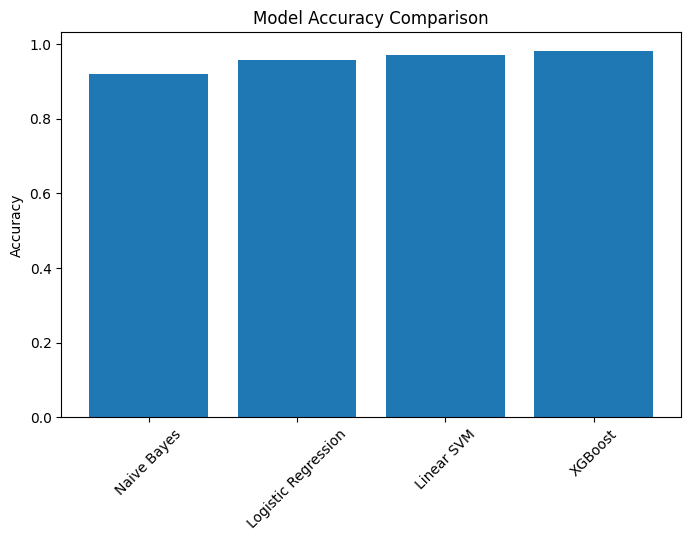

In [20]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

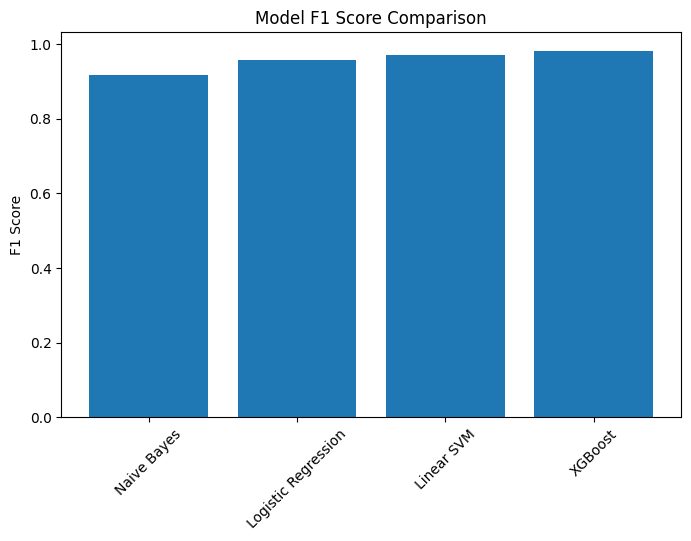

In [21]:
plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["F1 Score"])
plt.xticks(rotation=45)
plt.title("Model F1 Score Comparison")
plt.ylabel("F1 Score")
plt.show()

Best Model: XGBoost


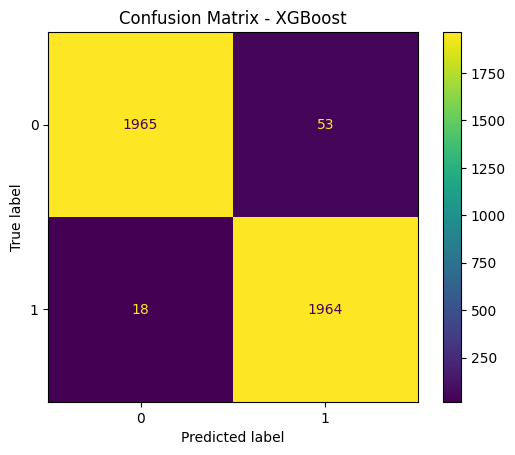

In [22]:
best_model_name = results_df.sort_values("F1 Score", ascending=False).iloc[0]["Model"]

print("Best Model:", best_model_name)

best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [23]:
# ===============================
# GRID SEARCH FOR SVM
# ===============================

param_grid = {
    'C': [0.1, 1, 10]
}

grid = GridSearchCV(LinearSVC(), param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation F1:", grid.best_score_)

d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  war

Best Parameters: {'C': 1}
Best Cross-Validation F1: 0.9669789012705089


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2018
           1       0.97      0.99      0.98      1982

    accuracy                           0.98      4000
   macro avg       0.98      0.98      0.98      4000
weighted avg       0.98      0.98      0.98      4000



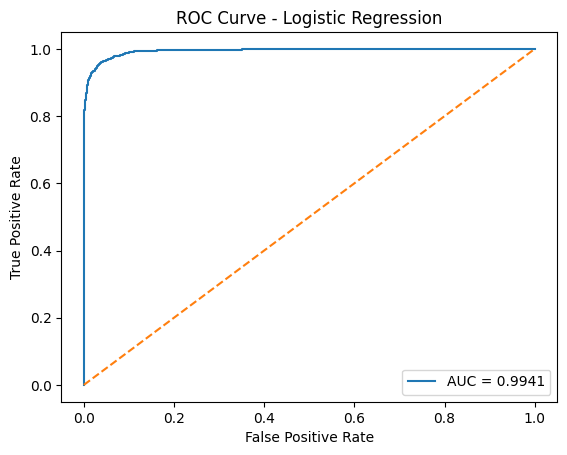

In [25]:
from sklearn.metrics import roc_curve, auc

model = models["Logistic Regression"]

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

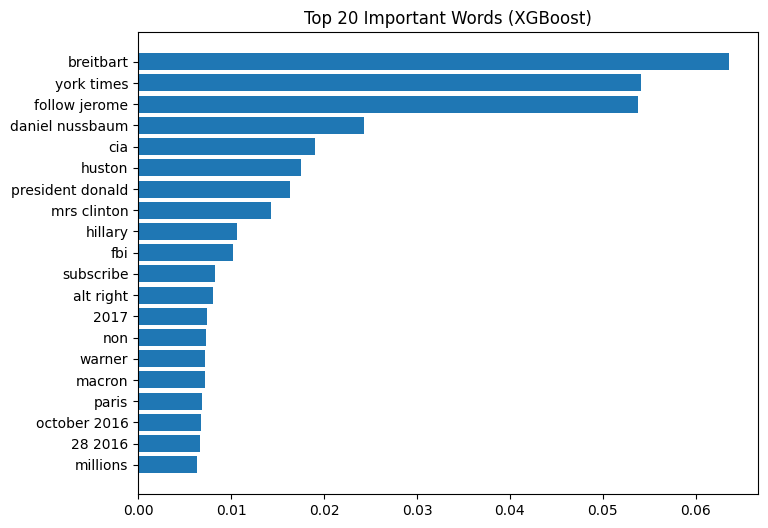

In [26]:
import numpy as np

importances = models["XGBoost"].feature_importances_

indices = np.argsort(importances)[-20:]

plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), 
           [vectorizer.get_feature_names_out()[i] for i in indices])
plt.title("Top 20 Important Words (XGBoost)")
plt.show()

In [27]:
errors = y_test != y_pred_best
print("Number of misclassified samples:", errors.sum())

Number of misclassified samples: 71


In [28]:
misclassified_indices = y_test[errors].index

df.loc[misclassified_indices][["full_text", "label"]].head()

,full_text,label
12167,Virgil: Donald Trump vs. the Main Stream Media...,0
6103,DELINGPOLE: Al Gore - Global Warming Is Real B...,0
8726,Delingpole: The Pause in Global Warming Is Rea...,0
13550,Planned Parenthood Bids Farewell to Pro-Aborti...,0
416,A nation ‘WRECKED’ by immigration: A civil war...,1


In [30]:
# ============================================
# TOP WORDS PER CLASS (Logistic Regression)
# ============================================

feature_names = vectorizer.get_feature_names_out()

log_model = models["Logistic Regression"]

coefs = log_model.coef_[0]

# Top words predicting FAKE (positive class)
top_fake_indices = np.argsort(coefs)[-20:]

# Top words predicting REAL (negative class)
top_real_indices = np.argsort(coefs)[:20]

print("Top 20 Words Predicting FAKE News:\n")
print([feature_names[i] for i in top_fake_indices])

print("\nTop 20 Words Predicting REAL News:\n")
print([feature_names[i] for i in top_real_indices])

Top 20 Words Predicting FAKE News:

['elect', 'old', 'election', 'comment', 'president elect', 'al', 'com', 'fbi', 'share', 'self', 'november 2016', 'source', 'non', 'clinton', 'year old', 'november', 'anti', 'october', 'hillary', '2016']

Top 20 Words Predicting REAL News:

['breitbart', 'said', 'mr', 'twitter', 'ms', 'york times', '2017', 'new york', 'york', 'follow', 'president donald', 'times', 'president trump', 'new', 'president', 'sunday', 'breitbart news', 'percent', 'march', 'milo']


In [31]:
# ============================================
# REAL-WORLD PREDICTION FUNCTION
# ============================================

def predict_news(text):
    text_vector = vectorizer.transform([text])
    
    model = models["Logistic Regression"]
    
    probability = model.predict_proba(text_vector)[0][1]
    prediction = model.predict(text_vector)[0]
    
    if prediction == 1:
        print(f"Prediction: FAKE News 🚨")
    else:
        print(f"Prediction: REAL News ✅")
        
    print(f"Confidence: {probability:.4f}")

In [32]:
predict_news("Breaking shocking secret government exposed click here to know truth")

Prediction: FAKE News 🚨
Confidence: 0.9859


In [33]:
predict_news("The government released an official statement regarding economic policy changes")

Prediction: FAKE News 🚨
Confidence: 0.7581


In [34]:
# ============================================
# WORD FREQUENCY COMPARISON
# ============================================

fake_text = df[df["label"] == 1]["full_text"]
real_text = df[df["label"] == 0]["full_text"]

from collections import Counter

fake_words = Counter(" ".join(fake_text).split())
real_words = Counter(" ".join(real_text).split())

print("Most common words in FAKE news:")
print(fake_words.most_common(10))

print("\nMost common words in REAL news:")
print(real_words.most_common(10))

Most common words in FAKE news:
[('the', 321828), ('of', 169431), ('to', 168891), ('and', 149452), ('a', 117521), ('in', 103267), ('that', 77389), ('is', 74569), ('for', 52223), ('on', 43029)]

Most common words in REAL news:
[('the', 462889), ('to', 237931), ('of', 231470), ('a', 215086), ('and', 199196), ('in', 168059), ('that', 111092), ('for', 80233), ('on', 75368), ('is', 70046)]


In [35]:
!pip install transformers torch

In [36]:
!pip install transformers torch

In [37]:
# ============================================
# BERT IMPORTS
# ============================================

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

d:\REPOS\Fake-News-Detection-PySpark\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
!pip install datasets

In [39]:
# ============================================
# BERT IMPORTS
# ============================================

import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import numpy as np

In [40]:
# ============================================
# PREPARE DATA FOR BERT
# ============================================

bert_df = df[["full_text", "label"]].copy()

bert_df = bert_df.sample(10000, random_state=42)  # limit size for speed

train_df, test_df = train_test_split(
    bert_df, test_size=0.2, random_state=42
)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [41]:
# ============================================
# TOKENIZER
# ============================================

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["full_text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 2000/2000 [00:19<00:00, 102.08 examples/s]


In [42]:
# ============================================
# LOAD MODEL
# ============================================

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [45]:
# ============================================
# TRAINING SETTINGS
# ============================================

training_args = TrainingArguments(
    output_dir="./bert_results",
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50
)

In [43]:
!pip install "accelerate>=0.26.0"

In [46]:
# ============================================
# CREATE TRAINER
# ============================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [50]:

# ============================================
# TRAIN MODEL
# ============================================

trainer.train()


  0%|          | 4/2000 [00:29<4:02:18,  7.28s/it]


KeyboardInterrupt: 

In [ ]:
import joblib

joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(models["Logistic Regression"], "fake_news_model.pkl")